In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data=pd.read_csv("/home/hammadali08/Vidoes/CSV file/Salary Data.csv")
data.drop(columns=['Age','Gender','Education Level','Job Title'],inplace=True)
data.fillna(data.mean(),inplace=True)
data

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0
...,...,...
370,8.0,85000.0
371,19.0,170000.0
372,2.0,40000.0
373,7.0,90000.0


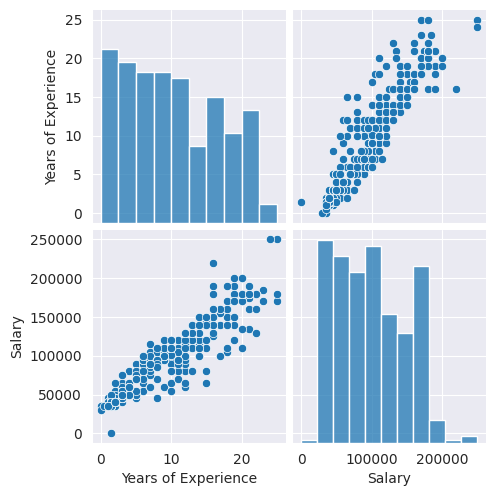

In [36]:
sns.pairplot(data)
plt.show()

In [37]:
x=data[['Years of Experience']]
y=data['Salary']

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [40]:
from sklearn.tree import DecisionTreeRegressor

In [81]:
dtr=DecisionTreeRegressor(max_depth= 4,splitter='best')

In [82]:
dtr.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=4)

In [83]:
dtr.score(x_test,y_test),dtr.score(x_train,y_train)

(0.885071820158666, 0.8830724272782715)

In [84]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [85]:
df={ 'criterion': ["squared_error", "absolute_error","poisson","friedman_mse"],
             'splitter':  ["best",'random'],
             'max_depth':[i for i in range(1,20)]}

In [86]:
gd=GridSearchCV(DecisionTreeRegressor(),df)

In [87]:
gd.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'poisson', 'friedman_mse'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19],
                         'splitter': ['best', 'random']})

In [88]:
gd.best_params_

{'criterion': 'squared_error', 'max_depth': 4, 'splitter': 'best'}

In [89]:
gd.best_score_

np.float64(0.8555504413256962)

In [90]:
rd=RandomizedSearchCV(DecisionTreeRegressor(),df,n_iter=20)

In [91]:
rd.fit(x_train,y_train)

RandomizedSearchCV(estimator=DecisionTreeRegressor(), n_iter=20,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error',
                                                      'poisson',
                                                      'friedman_mse'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'splitter': ['best', 'random']})

In [76]:
rd.best_params_

{'splitter': 'random', 'max_depth': 13, 'criterion': 'absolute_error'}

In [77]:
rd.best_score_

np.float64(0.8538095679805686)